The intent of this work is to make a AI systems able to predict students that are prone to dropout Highscholl. 
However, highschool datasets are really hard to find/ have access to in Brazil, so we are starting this project with 2 datasets that  simulates a realistic academic environment from Kaggle. Further more, I will use a dataset that's already being used on another study on my university. <br>The data bases links are:
*  https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset
*  https://www.kaggle.com/datasets/gabrielmarcano/evaso-escolar-cdac-150-linhas/data
*  https://www.kaggle.com/datasets/adilshamim8/predict-students-dropout-and-academic-success
*  https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
import seaborn as sns
import numpy as np

In [2]:
evasaoCDAC = pd.read_csv('data\dataset_evasao_cdac.csv')
studentDropout = pd.read_csv('data\student_dropout_dataset_v3.csv')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Vendas e Marketing\AppData\Local\Temp\ipykernel_8724\1150362824.py:1: SyntaxWarning: invalid escape sequence '\d'
  evasaoCDAC = pd.read_csv('data\dataset_evasao_cdac.csv')
C:\Users\Vendas e Marketing\AppData\Local\Temp\ipykernel_8724\1150362824.py:2: SyntaxWarning: invalid escape sequence '\s'
  studentDropout = pd.read_csv('data\student_dropout_dataset_v3.csv')


# evasaoCDAC   

Contains a dataset wich have 150 registers and the features are:
-  Student ID
-  Name
-  Nota Média 
-  Frequência (%) → Percentual de presença nas aulas.
-  Atividades Extracurriculares → Indica se o aluno participa de atividades fora do horário regular.

-  Absenteísmo → Número ou nível de faltas registradas.

-  Programa de Apoio → Indica se o aluno recebe suporte institucional (bolsas, reforço escolar etc.).

-  Participação nas Aulas (%) → Percentual de engajamento e participação efetiva nas aulas.

-  Evasão → Variável-alvo que indica se o aluno abandonou ou não a escola (Sim/Não).

In [3]:
evasaoCDAC.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID do Aluno                   150 non-null    int64  
 1   Nome                          150 non-null    str    
 2   Nota Media                    150 non-null    float64
 3   Frequencia (%)                150 non-null    int64  
 4   Atividades Extracurriculares  150 non-null    str    
 5   Absenteismo                   150 non-null    int64  
 6   Programa de Apoio             150 non-null    str    
 7   Participacao nas Aulas (%)    150 non-null    int64  
 8   Evasao                        150 non-null    str    
dtypes: float64(1), int64(4), str(4)
memory usage: 10.7 KB


# studentDropout 


Has the features:
-  Student_ID             
-   Age                    
-   Gender                 
-   Family_Income          
-   Internet_Access        
-   Study_Hours_per_Day    
-   Attendance_Rate        
-   Assignment_Delay_Days  
-   Travel_Time_Minutes    
-   Part_Time_Job           
-  Scholarship            
-  Stress_Index           
-  GPA                    
-  Semester_GPA          
-  CGPA                   
-  Semester               
-  Department              
-  Parental_Education      
-  Dropout

However, Family_Income, Study_Hours_per_Day, Stress_Index and Parental education has aproximately 500 missing registers

In [4]:
studentDropout.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

First things first, we have to explore how the data works itself, so let's make some analysis!

In [5]:
studentDropout.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


Now we gotta __remove__ every null information! This leaves us with 9020 registers total.

In [6]:
studentDropout.dropna(inplace=True)

We will turn every pramether into a number.

In [7]:
print(studentDropout['Gender'].unique())
print(studentDropout['Internet_Access'].unique())
print(studentDropout['Part_Time_Job'].unique())
print(studentDropout['Scholarship'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [8]:
studentDropout['Gender']= pd.to_numeric(studentDropout['Gender'].replace('Male','1').replace('Female', '0'), errors='coerce')
studentDropout['Internet_Access']= pd.to_numeric(studentDropout['Internet_Access'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Part_Time_Job']= pd.to_numeric(studentDropout['Part_Time_Job'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Scholarship']= pd.to_numeric(studentDropout['Scholarship'].replace('Yes','1').replace('No', '0'), errors='coerce') 
studentDropout['Semester']= pd.to_numeric(studentDropout['Semester'].str.replace('Year ',''), errors='coerce')

In [9]:
studentDropout['Internet_Access']= pd.to_numeric(studentDropout['Internet_Access'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Part_Time_Job']= pd.to_numeric(studentDropout['Part_Time_Job'].replace('Yes','1').replace('No', '0'), errors='coerce')
studentDropout['Scholarship']= pd.to_numeric(studentDropout['Scholarship'].replace('Yes','1').replace('No', '0'), errors='coerce') 


Now, let's make and index for each of the departments and parental education

In [10]:
parentalEducationLevels = studentDropout['Parental_Education'].unique()
studentDropout['Parental_Education'] = studentDropout['Parental_Education'].astype('category').cat.codes
departments = studentDropout['Department'].unique()
studentDropout['Department'] = studentDropout['Department'].astype('category').cat.codes

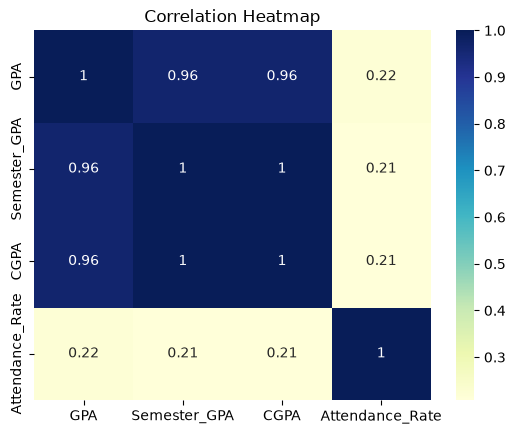

In [11]:
sns.heatmap(studentDropout[['GPA', 'Semester_GPA', 'CGPA', 'Attendance_Rate']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

Looking at this heatmap we can see that only the GPA, Semester_GPA and CGPA explain the same thing. So we can choose only one of them. 
We don't need the student ID for this too, since its only an indentifier

In [12]:
studentDropout.drop(columns=['Student_ID', 'Semester_GPA', 'CGPA'], inplace=True)

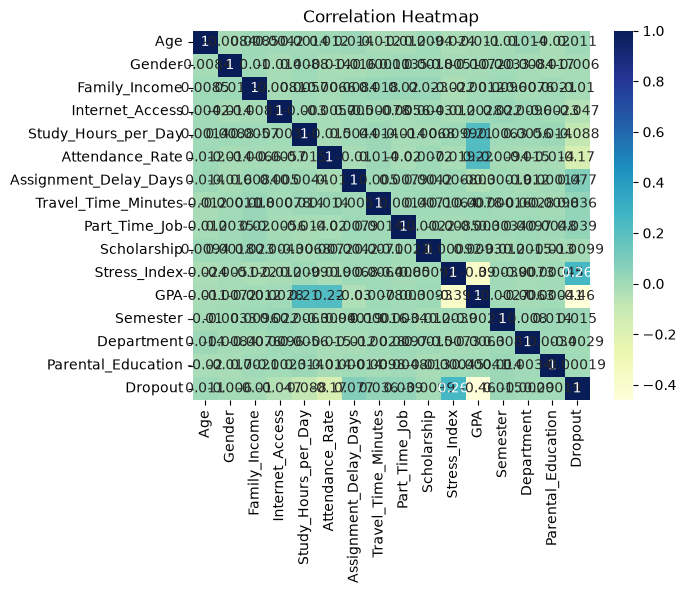

In [13]:
sns.heatmap(studentDropout.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

# df_PT

In [14]:
df_PT = pd.read_csv('data/data.csv', sep=';')

In [15]:
df_PT.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [16]:
df_PT['Target'] = df_PT['Target'].replace('Graduate', 0).replace('Enrolled', 0).replace('Dropout', 1)

### Variáveis
- Todas as variáveis estão oficialmente em int ou float, garantindo que consiguimos comparar eles de maneira numérica

In [17]:
binary = [
    'Gender',
    'Displaced',
    'Scolarship Holder',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date'
]

Continuous= [
    'Admission grade',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

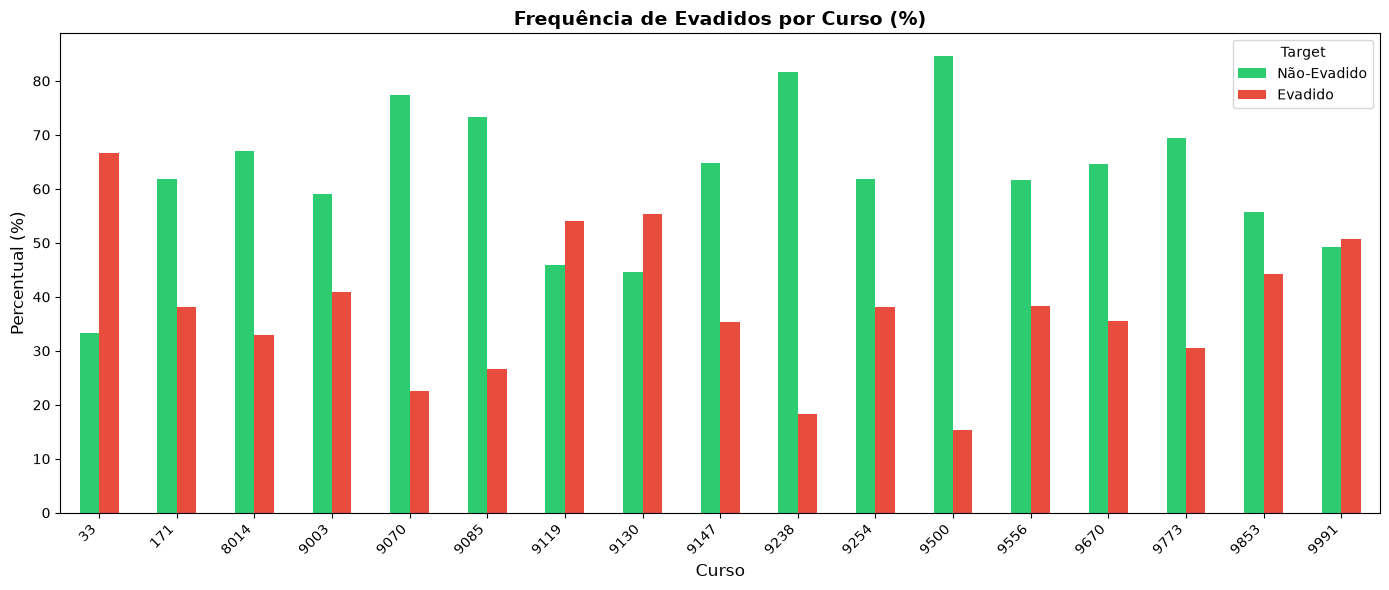

In [18]:
# Gráfico de frequência de evadidos por curso (em percentual)
plt.figure(figsize=(14, 6))

# Contagem de evadidos vs não-evadidos por curso
course_target = pd.crosstab(df_PT['Course'], df_PT['Target'])

# Converter para percentual
course_target_pct = course_target.div(course_target.sum(axis=1), axis=0) * 100

course_target_pct.plot(kind='bar', ax=plt.gca(), color=['#2ecc71', '#e74c3c'], stacked=False)

plt.title('Frequência de Evadidos por Curso (%)', fontsize=14, fontweight='bold')
plt.xlabel('Curso', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.legend(title='Target', labels=['Não-Evadido', 'Evadido'], fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Contar quantidade de evadidos e não-evadidos
contagem = df_PT['Target'].value_counts().sort_index()
print("Quantidade de Estudantes por Status:")
print(f"Não-Evadidos: {contagem[0]}")
print(f"Evadidos: {contagem[1]}")
print(f"\nTotal: {contagem.sum()}")
print(f"\nPercentual de Evadidos: {(contagem[1] / contagem.sum() * 100):.2f}%")

Quantidade de Estudantes por Status:
Não-Evadidos: 3003
Evadidos: 1421

Total: 4424

Percentual de Evadidos: 32.12%


c:\Users\Vendas e Marketing\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\Vendas e Marketing\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


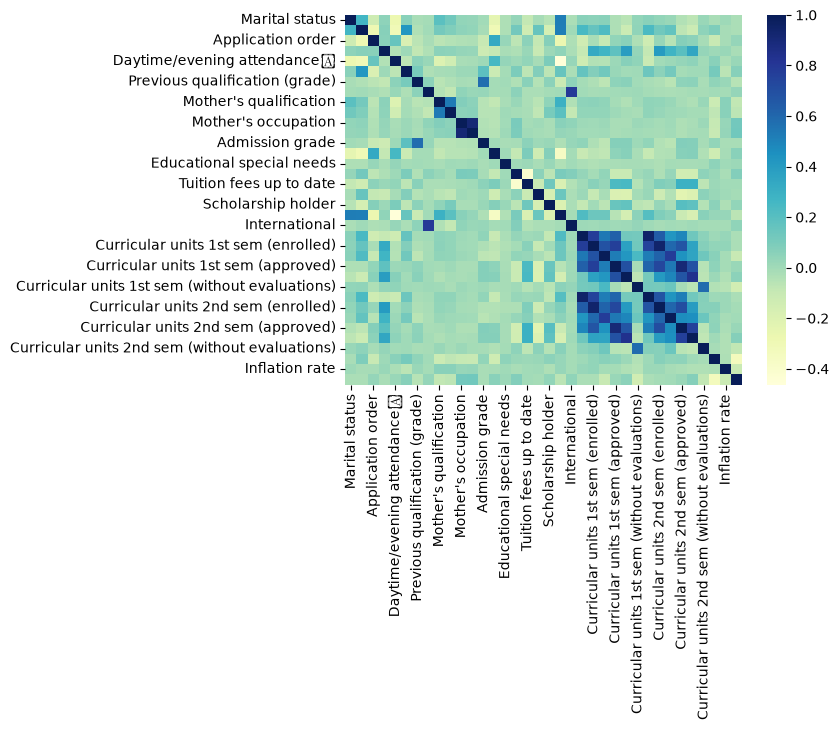

<Figure size 1200x1000 with 0 Axes>

In [20]:
plot = [col for col in df_PT.columns if col != 'Target']
sns.heatmap(df_PT[plot].corr(), cmap='YlGnBu')
plt.figure(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [21]:
drop = [col for col in df_PT.columns if col.startswith('Curricular units 2nd sem') and col != 'Curricular units 2nd sem (without evaluations)'] + ['Father\'s occupation', 'International']
df_PT.drop(columns=drop, inplace=True)

c:\Users\Vendas e Marketing\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


<Axes: >

C:\Users\Vendas e Marketing\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


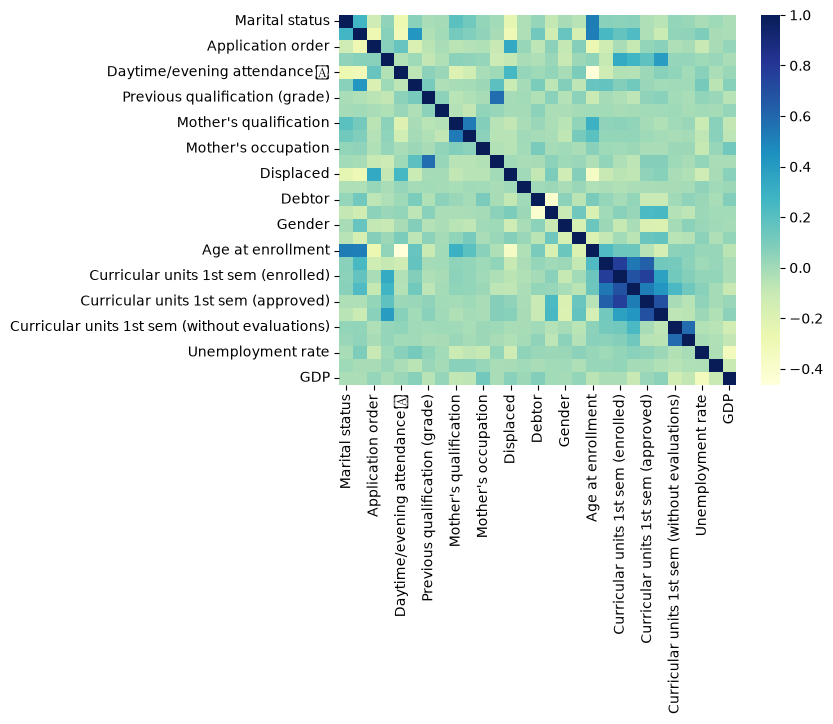

In [22]:
plot = [col for col in df_PT.columns if col != 'Target']
sns.heatmap(df_PT[plot].corr(), cmap='YlGnBu')

# Coding
Now that we cleaned our database and treated any thing that could cause trouble, it's time we start coding

## Decision Tree

In [23]:
import sklearn.model_selection

y = df_PT['Target']
X = df_PT.drop(columns=['Target'])

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
class Question():
    def __init__(self, column, value):
        self.column = column
        self.value = value
    
    def match(self, example):
        val =example[self.column]
        if isinstance(val, (int, float)):
            return val >= self.value
        else:
            return val == self.value

    def __repr__(self):
        condition = "=="
        if isinstance(self.value, (int, float)):
            condition = ">="
        return f"Is {self.column} {condition} {str(self.value)}?"

In [62]:

def partition(rows, y, question):
    """
    Divide os dados de cada uma das linhas em duas listas,
    A primeira tem todos aqueles que respondem a pergunta;
    Já a segunda tem todos aqueles que não respondem a pergunta.
    """
    true_rows, false_rows = [], []
    true_labels, false_labels = [], []

    for row, label in zip(rows, y):
        if question.match(row):
            true_rows.append(row)
            true_labels.append(label)
        else:
            false_rows.append(row)
            false_labels.append(label)

    true_rows = np.array(true_rows)
    true_labels = np.array(true_labels)
    false_rows = np.array(false_rows)
    false_labels = np.array(false_labels)

    return (true_rows, true_labels), (false_rows, false_labels)

def class_counts(rows):  
    #Lista quantas vezes aparece na coluna de evasão os evadidos e não evadidos 
    counts = {}
    for row in rows:
        label = row[-1]
        if label not in counts:
            counts[label]=1
        else: 
            counts[label]+=1
    return counts


def gini(rows):
    counts =class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_lbl = counts[lbl]/float(len(rows))
        impurity -= prob_lbl**2

    return impurity

def info_gain(left, right, current_uncertainty):
    p = float(len(left))/(len(left) + len(right))
    return current_uncertainty - p *gini(left) - (1-p) * gini(right)
    
def find_best_split(rows, y, n_features):
    """
    Define a melhor pergunta para dividir os dados com base 
    no ganho de conhecimento (information gain) e no índice de Gini.
    """
    best_gain = 0
    best_question = None
    curr_gini = gini(rows)

    for col in range(n_features):
        values = set([row[col] for row in rows])

        for val in values:
                  
            question = Question(col, val)
            true_rows, false_rows = partition(rows, y, question)

            if len(true_rows) and len(false_rows):
                gain = info_gain(true_rows[0], false_rows[0], curr_gini)
                if gain >= best_gain: best_gain, best_question = gain, question

    return best_gain, best_question

In [63]:
class DecisionNode():
    #Tem filhos, é uma etapa de pergunta, e não uma folha da árvore de decisão.
    def __init__(self, question, true_branch, false_branch):
        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch

class Leaf():
    #Não tem filhos, é a resposta final da árvore de decisão.
    def __init__(self, rows):
        self.predictions = class_counts(rows).mode(0)

In [76]:
class DecisionTree():
    def __init__(self, x, y, minSplit = 2, maxDepth = 5, n_features=29):
        self.x = x
        self.y = y
        self.minSplit = minSplit
        self.maxDepth = maxDepth
        self.n_features = n_features
        
    def buildTree(self, curr_depth = 0):
        #Constrói a árvore de decisão recursivamente.
        n_samples= len(self.x)
        if n_samples < self.minSplit or self.maxDepth == 0:
            return Leaf(self.y)
        self.maxDepth -= 1
        gain, question = find_best_split(self.x, self.y, self.n_features)

        if gain == 0:
            return Leaf(self.y)
        (true_rows, true_labels), (false_rows, false_labels) = partition(self.x, self.y, question)


        if len(true_rows) == 0 or len(false_rows) == 0:
            return Leaf(self.y)
        
        curr_depth =+ 1
        true_branch = DecisionTree(true_rows, true_labels, self.minSplit, self.maxDepth).buildTree(curr_depth)
        false_branch = DecisionTree(false_rows, false_labels, self.minSplit, self.maxDepth).buildTree(curr_depth)

        return DecisionNode(question, true_branch, false_branch)

        
    def predict(self, row):
        if isinstance(self, Leaf):
            return self.predictions
        if self.question.match(row):
            return self.true_branch.predict(row)
        else:
            return self.false_branch.predict(row)
        
    def predict_all(self, rows):
        return [self.predict(row) for row in rows]

In [77]:
myTree = DecisionTree(X_train.values, y_train.values)
myTree.buildTree()
predictions = myTree.predict_all(X_test.values)
acuracy = np.mean(predictions == y_test.values)

IndexError: invalid index to scalar variable.

In [70]:
rows = np.array([[1, 2], [3, 4], [5, 6]])
y = np.array([0, 1, 0])
question = Question(0, 3)  # Example question
(true_rows, true_labels), (false_rows, false_labels) = partition(rows, y, question)
print("True Rows:", true_rows)
print("False Rows:", false_rows)

True Rows: [[3 4]]
False Rows: [[1 2]
 [5 6]]


## Random Forest


Random forets são um coletivo de árvores de decisão treinadas com um conjunto de dados selecionados aleatoriamente e com reposição em um data set. Além disso, os features analisados são também escolhidos de maneira aleatória

In [ ]:
from collections import Counter


class randomForest():
    def __init__(self, n_trees=10, minSplit=2, maxDepth=5, sample_size=10):
        self.n_trees = n_trees
        self.minSplit = minSplit
        self.maxDepth = maxDepth
        self.sample_size = sample_size
        self.trees = []

    def buildForest(self, x, y):
        for i in range(self.n_trees):
            new_x = x.sample(n=self.sample_size, replace=True)
            new_y = y[new_x.index]
            tree = DecisionTree(new_x, new_y, self.minSplit, self.maxDepth)
            self.trees.append(tree.buildTree())
        
        return self.trees
    
    def predict(self, row):
        predictions = [tree.predict(row) for tree in self.trees]
        
        count = Counter(predictions)
        classe_mais_votada, _ = count.most_common(1)[0]
        
        return classe_mais_votada
    
    def predict_all(self, rows):
        return [self.predict(row) for row in rows]

In [ ]:
myForest = randomForest()
myForest.buildForest(X_train.values, y_train.values)

predictionsForest = myForest.predict_all(X_test.values)
acuracyForest = np.mean(predictionsForest == y_test.values)

## ICRM

In [ ]:
df_PT.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,14.000000,0,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,8,6,13.428571,0,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,9,5,12.333333,0,0,13.9,-0.3,0.79,0


BEGIN
1. To initialise classifier
It creates two empty rule-set: one for dropout class and
another for success class.
2. To obtain the rules for predicting the dropout class
It runs GBGP algorithm in order to obtain a set of rules
that predicts the success class
3. To obtain the rules for predicting the success class
It runs GBGP algorithm in order to obtain a set of rules
that predicts the success class
4. To obtain the final rule-base classifier
It combines the rule-sets for the dropout and the success
classes to build the final classifier
  
END

In [ ]:
class ICRM():


SyntaxError: expected '(' (2550426449.py, line 1)

### GBGP

BEGIN  
    WHILE there are remaining instances and the number of
    rules is lower than the maximum allowed REPEAT  
    1.1. To initialise the population for a class  
    It generates the individuals (rules) of the population to
    learn a given class.  
    1.2. To do parent selection  
    It selects the parents on which the genetic operations are
    applied  
    1.3. To do crossover  
    It mixes the genetic information of the parents to
    generate an offspring  
    1.4. To do mutation  
    It mutates the offspring to facilitate the search
    exploration  
    1.5. To evaluate  
    It evaluates the fitness of the new rules  
    1.6. To update population  
    It selects the best rules from the parent population and
    the offspring to keep the population size constant with
    the best rules for the next generation  
    1.7. IF the algorithm has more generations to run  
    GOTO step 1.2 and iterate next generation  
    ELSE  
    CONTINUE with step 1.8  
    1.8. To select the best rule and append to the rule-set  
    It selects the best rule from the population using the
    fitness function and appends to the rule-set  
    1.9. To remove the instances covered by the rule  
    Instances covered by the rule are removed from the
    training examples so that new rules can be learned on the
    remaining instances  
    END WHILE  
    2. To return the rule-set  
END

In [ ]:
from random import random


class GBGP():
    def __init__(self, X, mutation_rate=0.1, crossover_rate=0.8, population_size=100, generations=50):
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.population_size = population_size
        self.generations = generations
        self.population=[]
        self.X = X
        self.n_features = len(X.columns)

    def random_population(self):
        for i in range(self.population_size):
            features=[]
            for _ in range(self.n_features):
                if self.X.columns[i] in binary:
                    features.append(random.randint(0,1))
                else:
                    features.append(random.choice(self.X.iloc[:, i].unique()))
            self.population.append(features)
    
    def mutation (self):
        for i in range(self.population_size):
            for j in range(self.n_features):
                if random.random() < self.mutation_rate:
                    if self.X.columns[j] in binary:
                        self.population[i][j] = 1 - self.population[i][j]
                    elif self.X.columns[j] in Continuous:
                        lim_max = self.X.iloc[:, j].max()
                        lim_min = self.X.iloc[:, j].min()
                        desvio_padrão = (lim_max - lim_min) * 0.05
                        novo_valor = self.population[i][j] + random.gauss(0, desvio_padrão)
                        self.population[i][j] = max(lim_min, min(lim_max, novo_valor))
                    else:
                        novo = self.population[i][j]
                        while novo == self.population[i][j]:
                            novo = random.choice(self.X.iloc[:, j].unique())
                        self.population[i][j] = novo
    
    def fitness(self, individual, X, y):


    

    def test_individual(self, individual, X):
        selected_features = [i for i in range(len(individual)) if individual[i]]


# Comparação dos resultados